# Платформа для видеоконференций. Персональное предложение продления подписки со скидкой. Дизайн А/B/С-эксперимента

## Executive summary

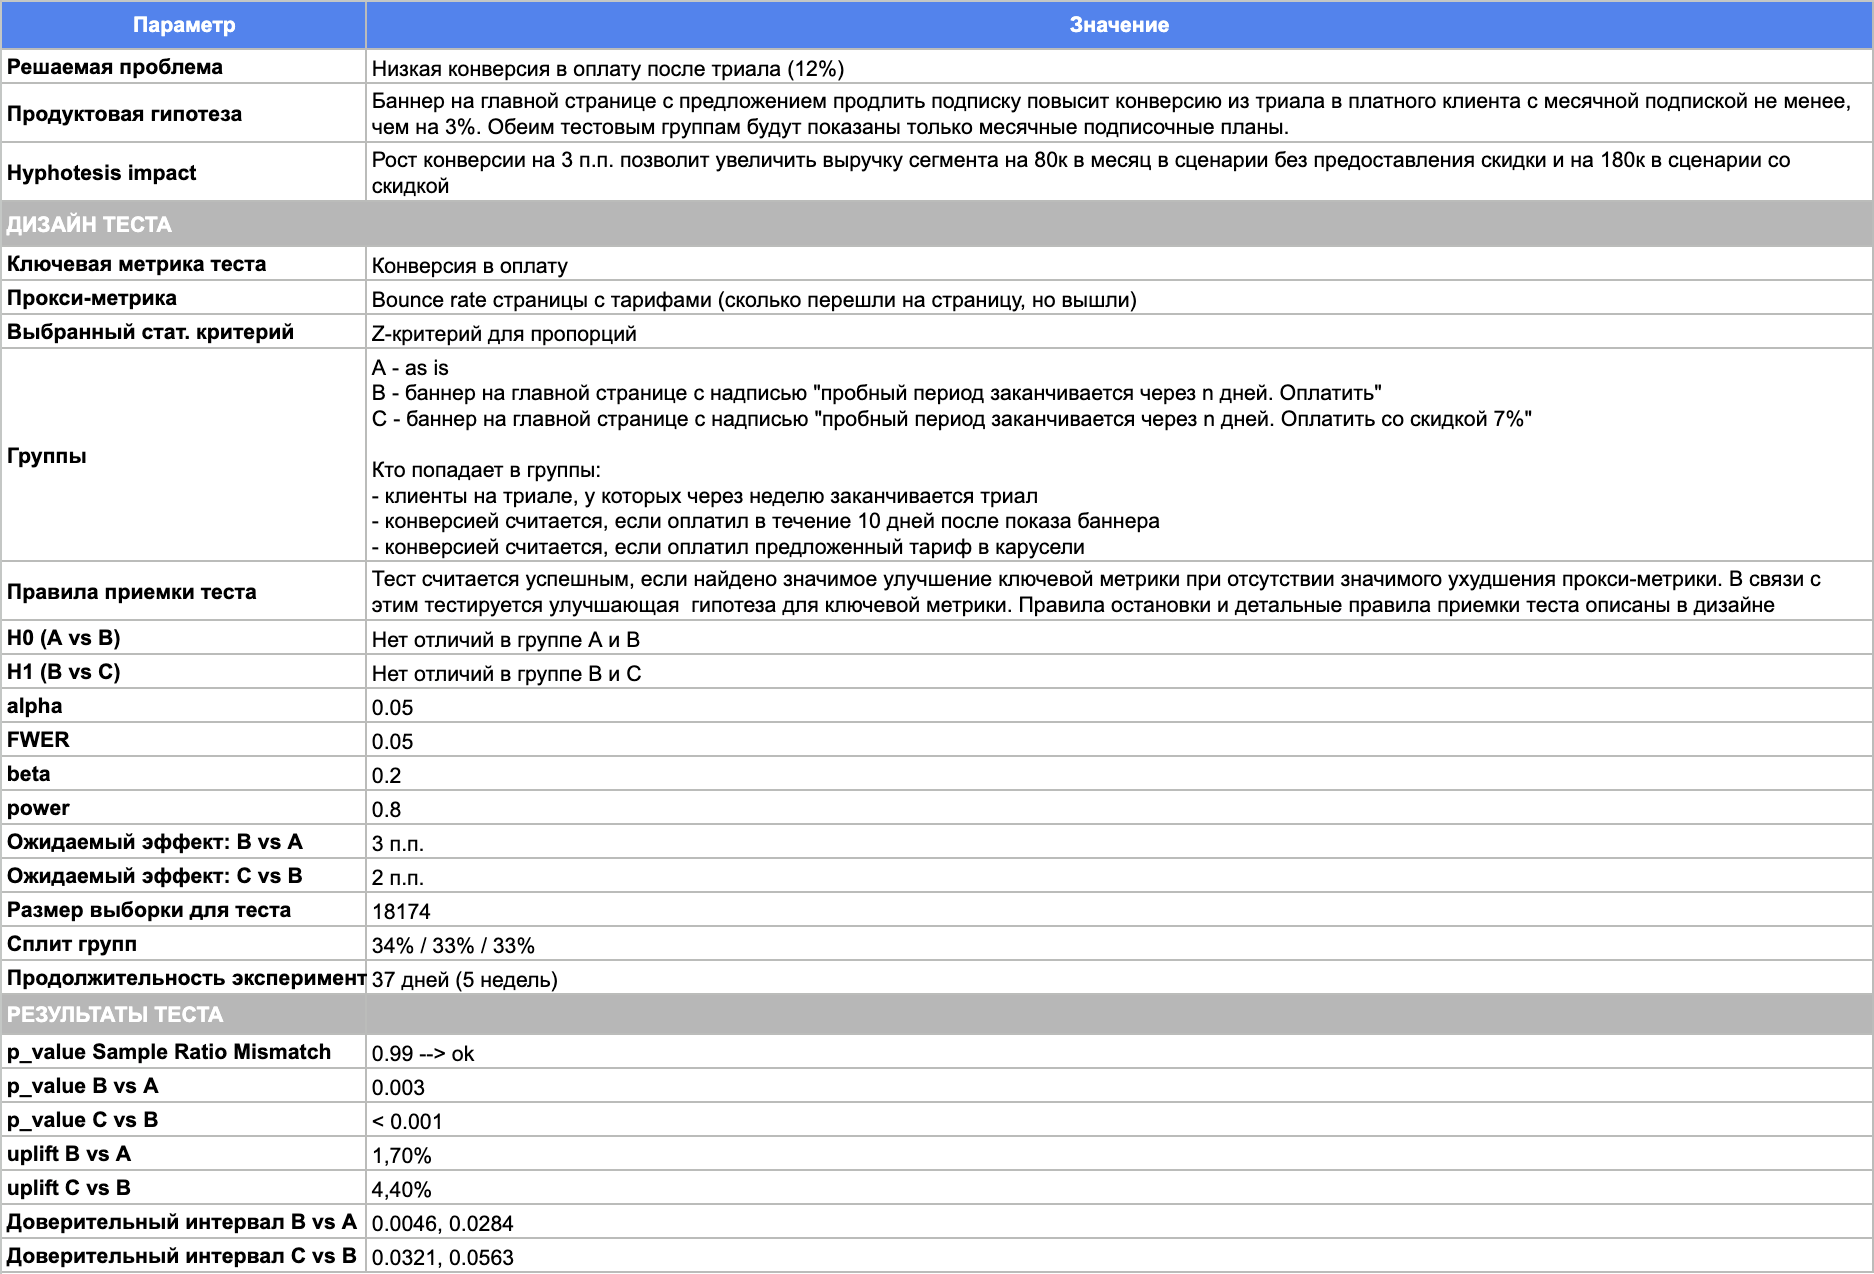

## Описание кейса

Проблема: в продукте стабильно стабильно низкая конверсия в подписку после триала. Предполагаем, что у большинства подключающих сервис через триал почти сразу пропадает необходимость заходить и пользоваться приложением регулярно, т.е. подписку они оформляют для 1 или нескольких онлайн встреч. Вместе с этим, есть гипотеза, что не продлеваются они т.к. забывают об этом. Мы предполагаем, что если вовремя напомнить, то конверсия в подписку вырастет.

Что предлагается сделать: в интерфейсе Контур-Толк сделать баннер "Продлить подписку".
Контрольной группе показать баннер с надписью “подписка заканчивается через n дней — продлить”
Тестовой группе показать баннер с надписью "подписка заканчивается через n дней - продлить со скидкой 7%"

## Контрольная группа

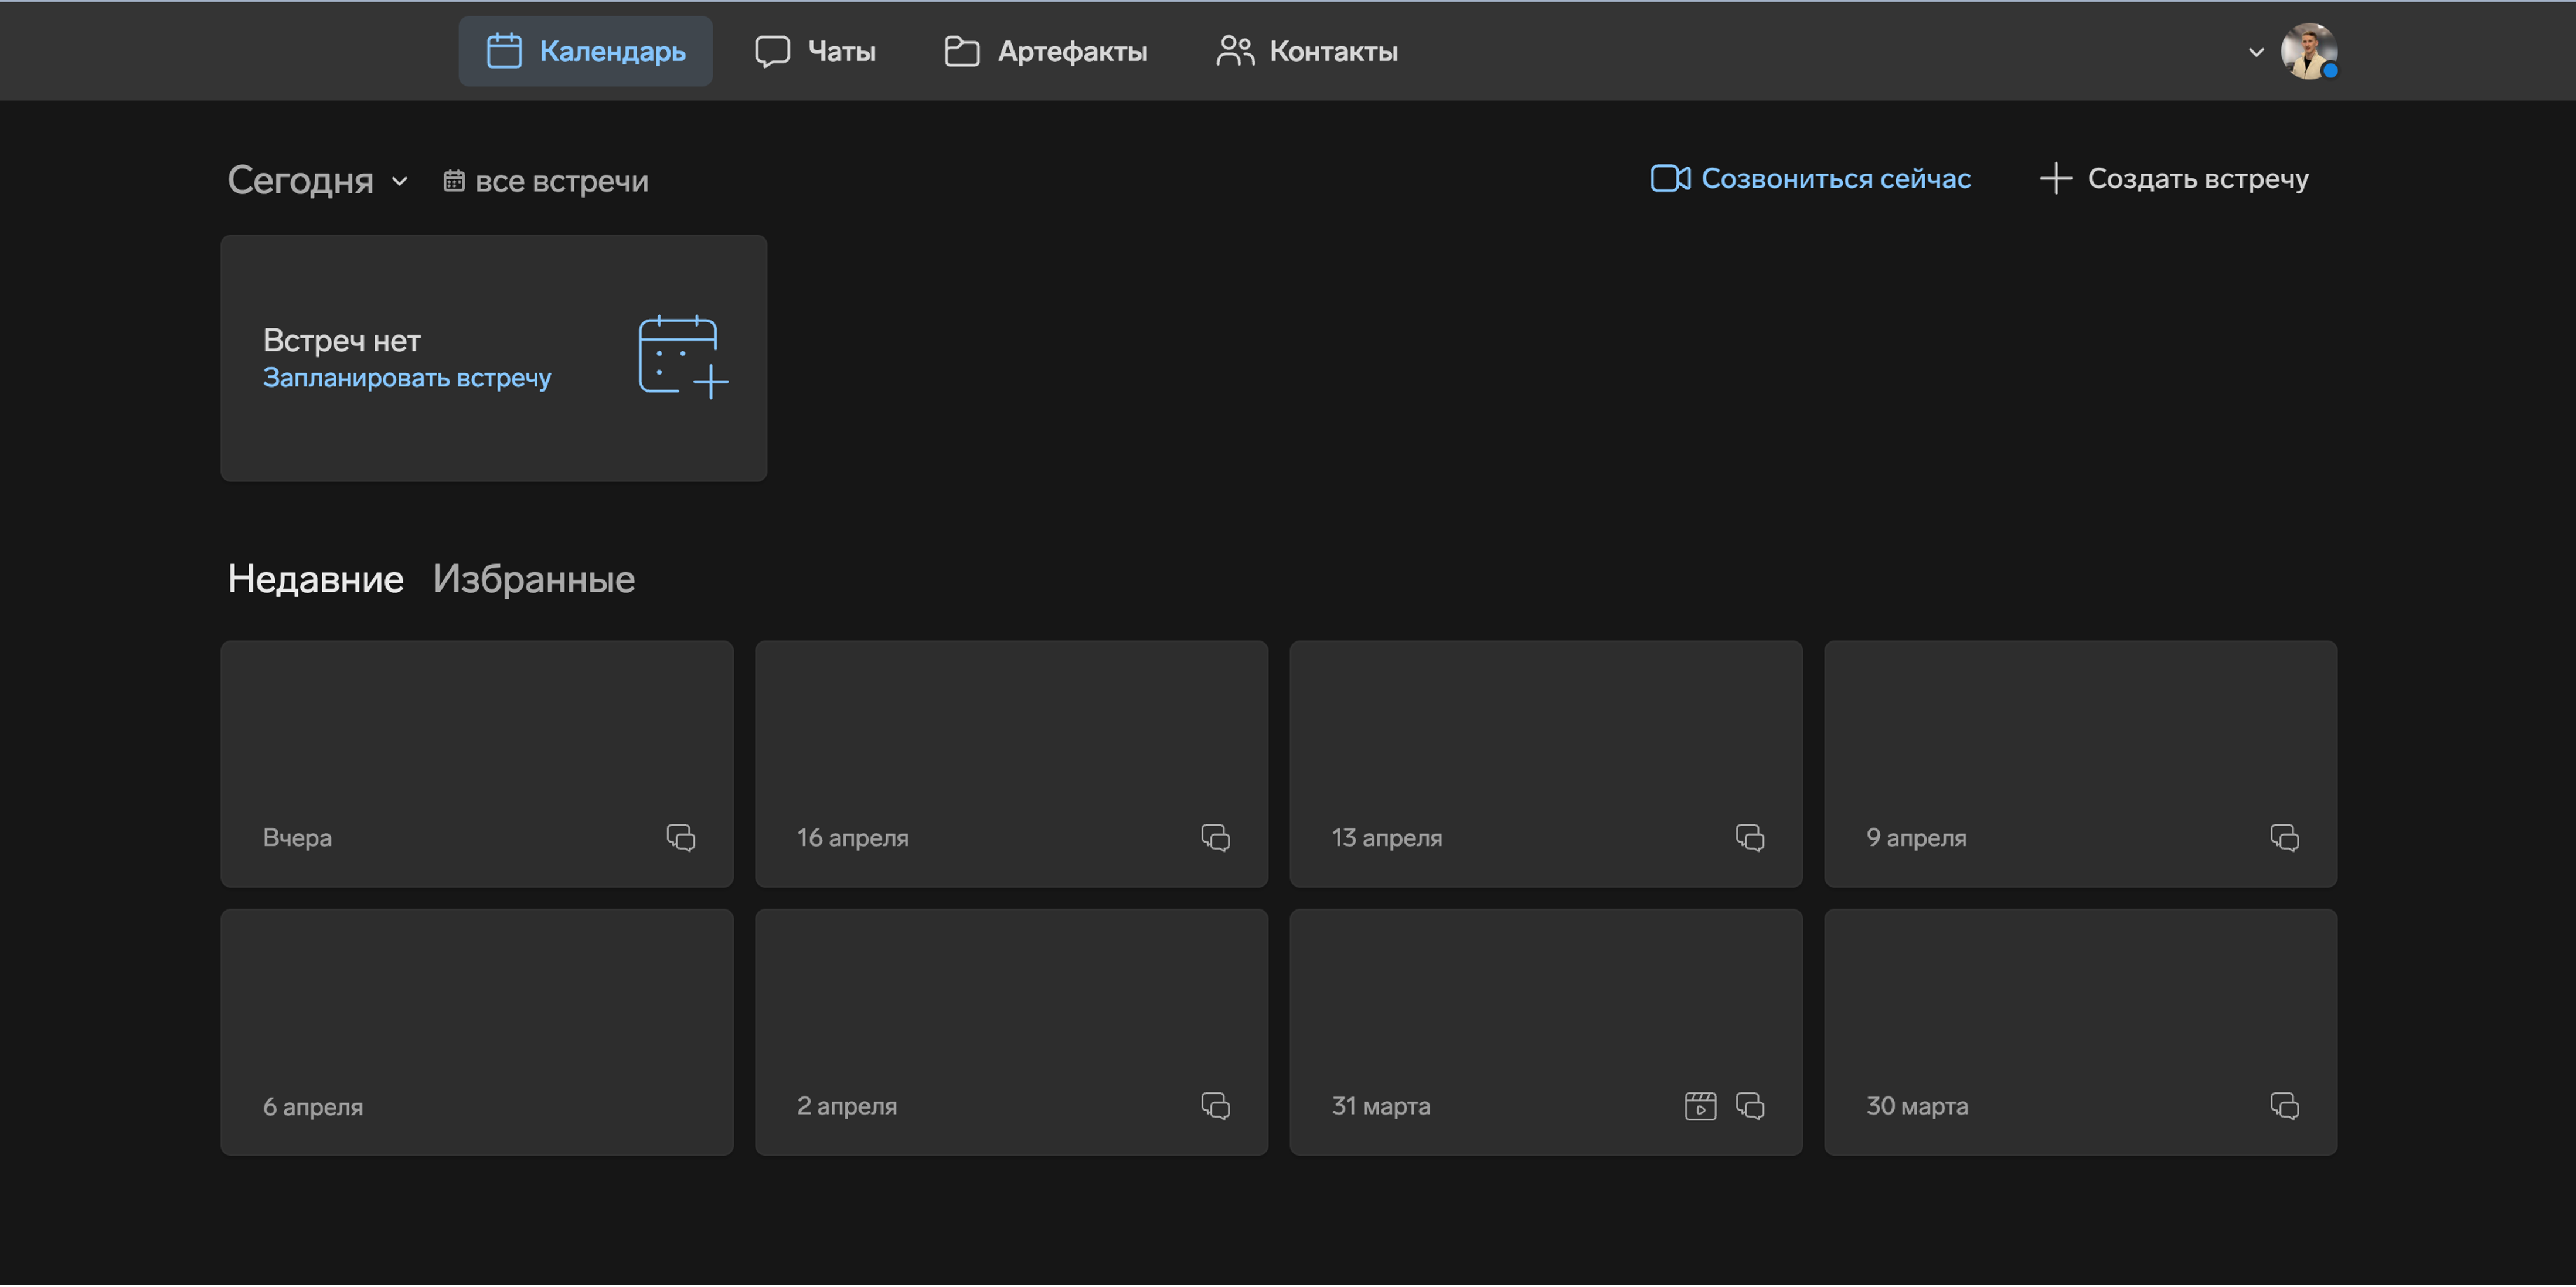

## Тестовая группа 1

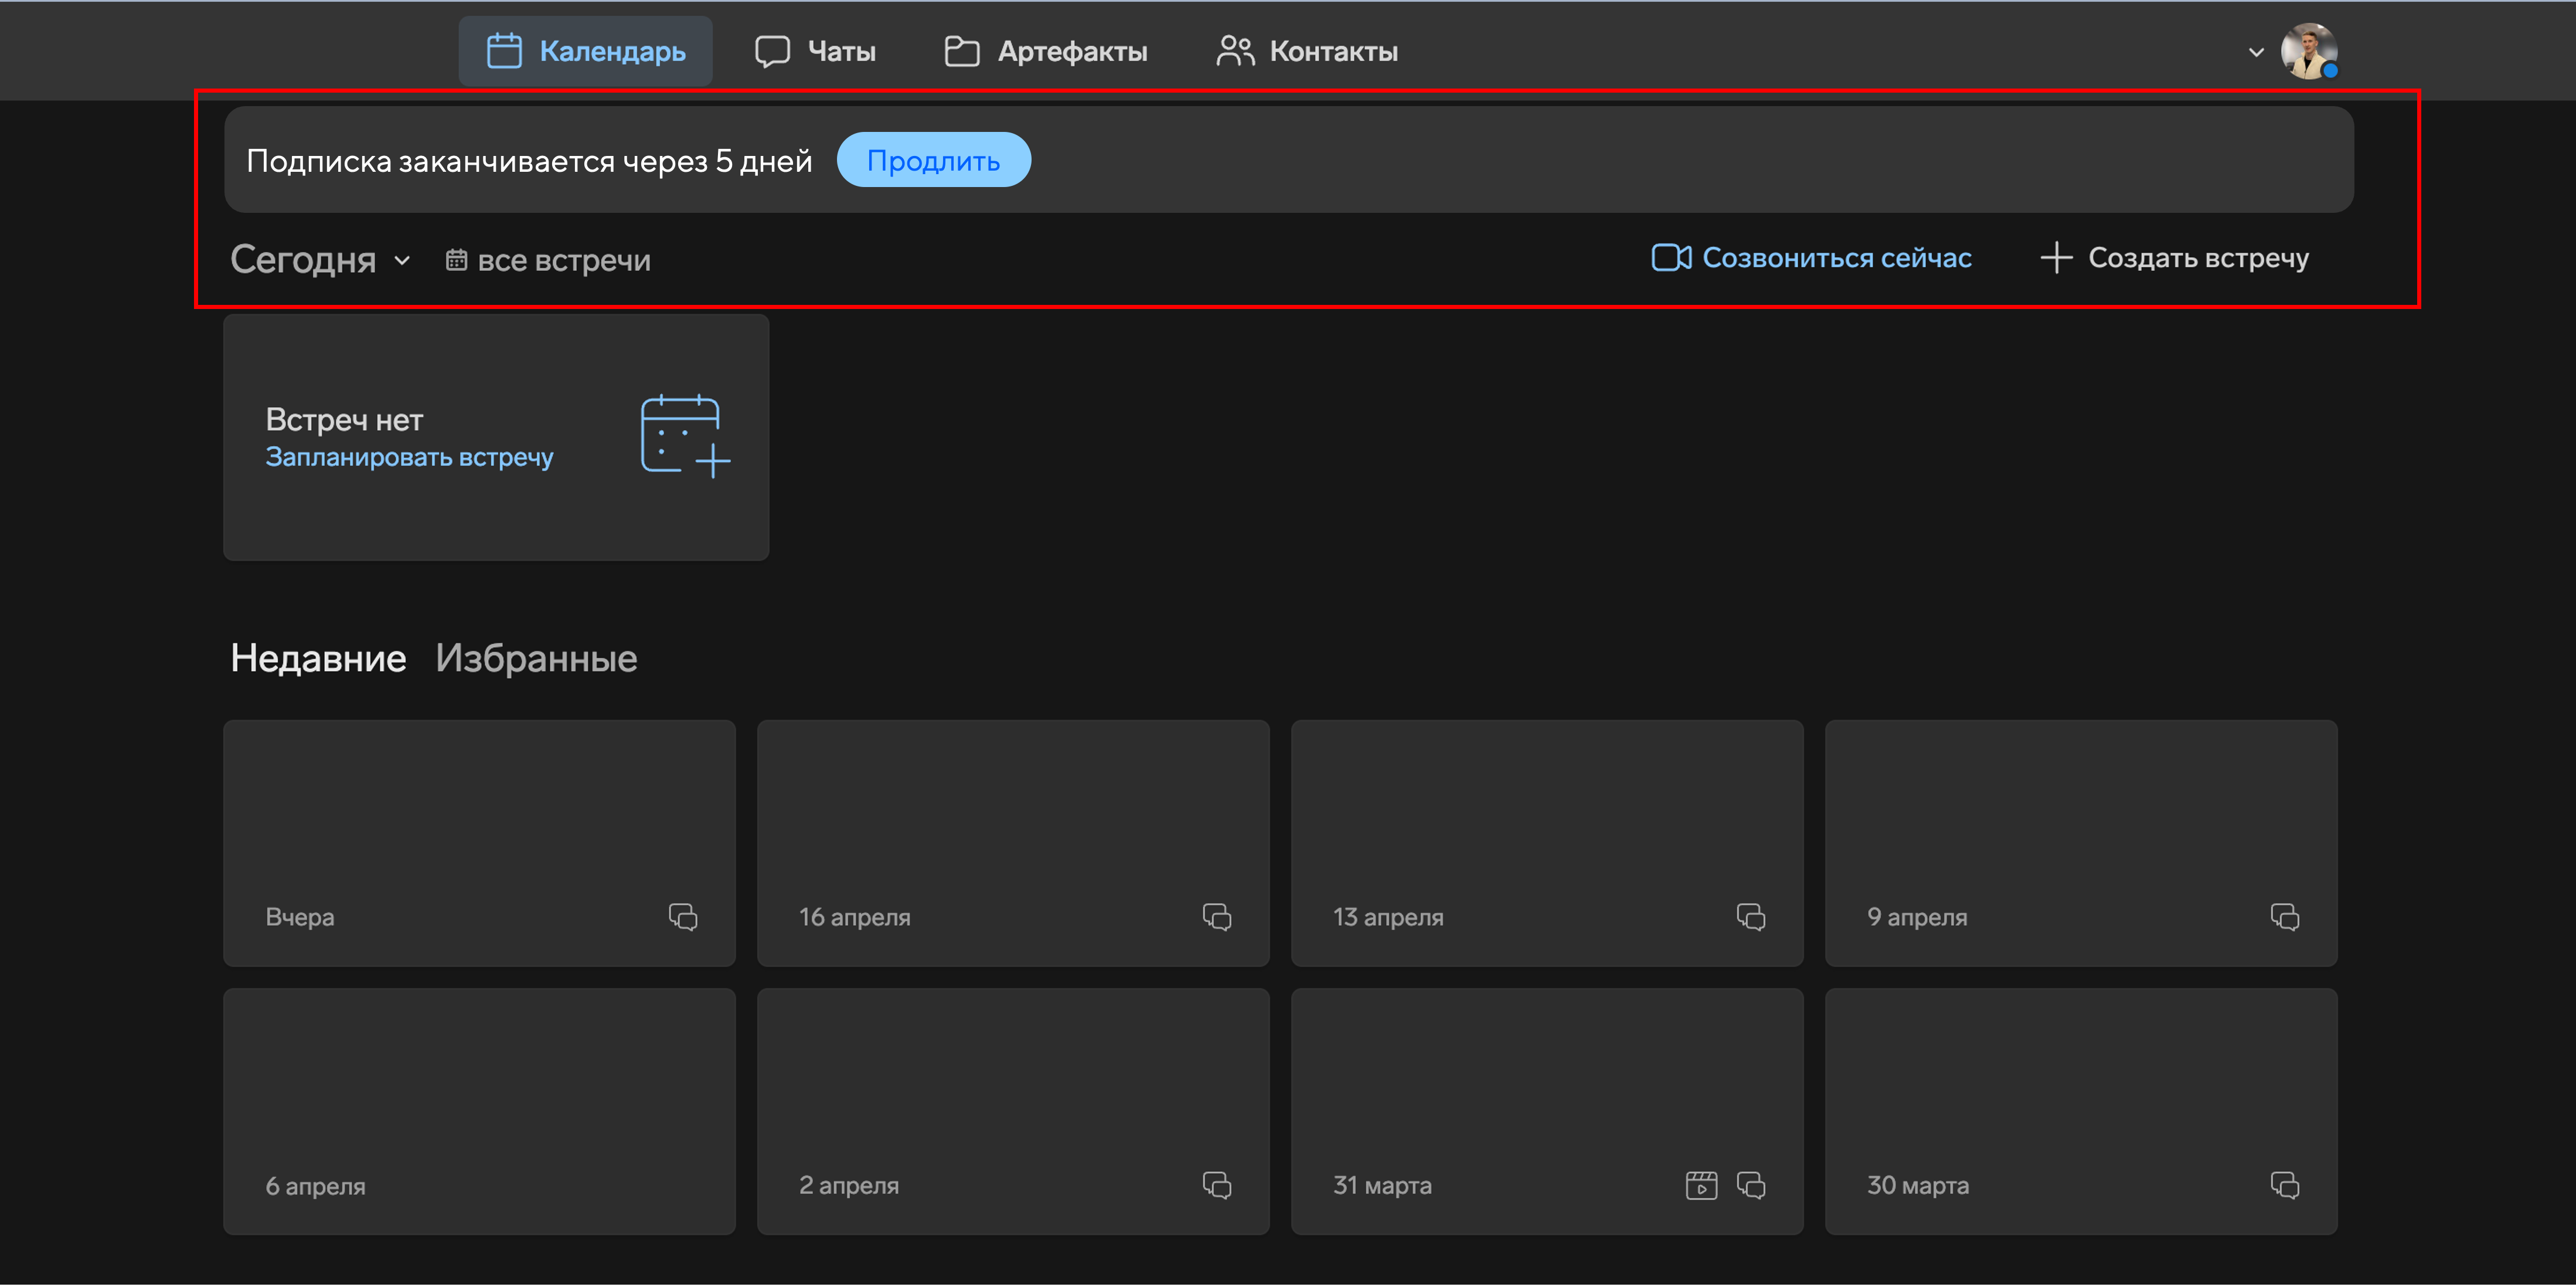

## Тестовая группа 2

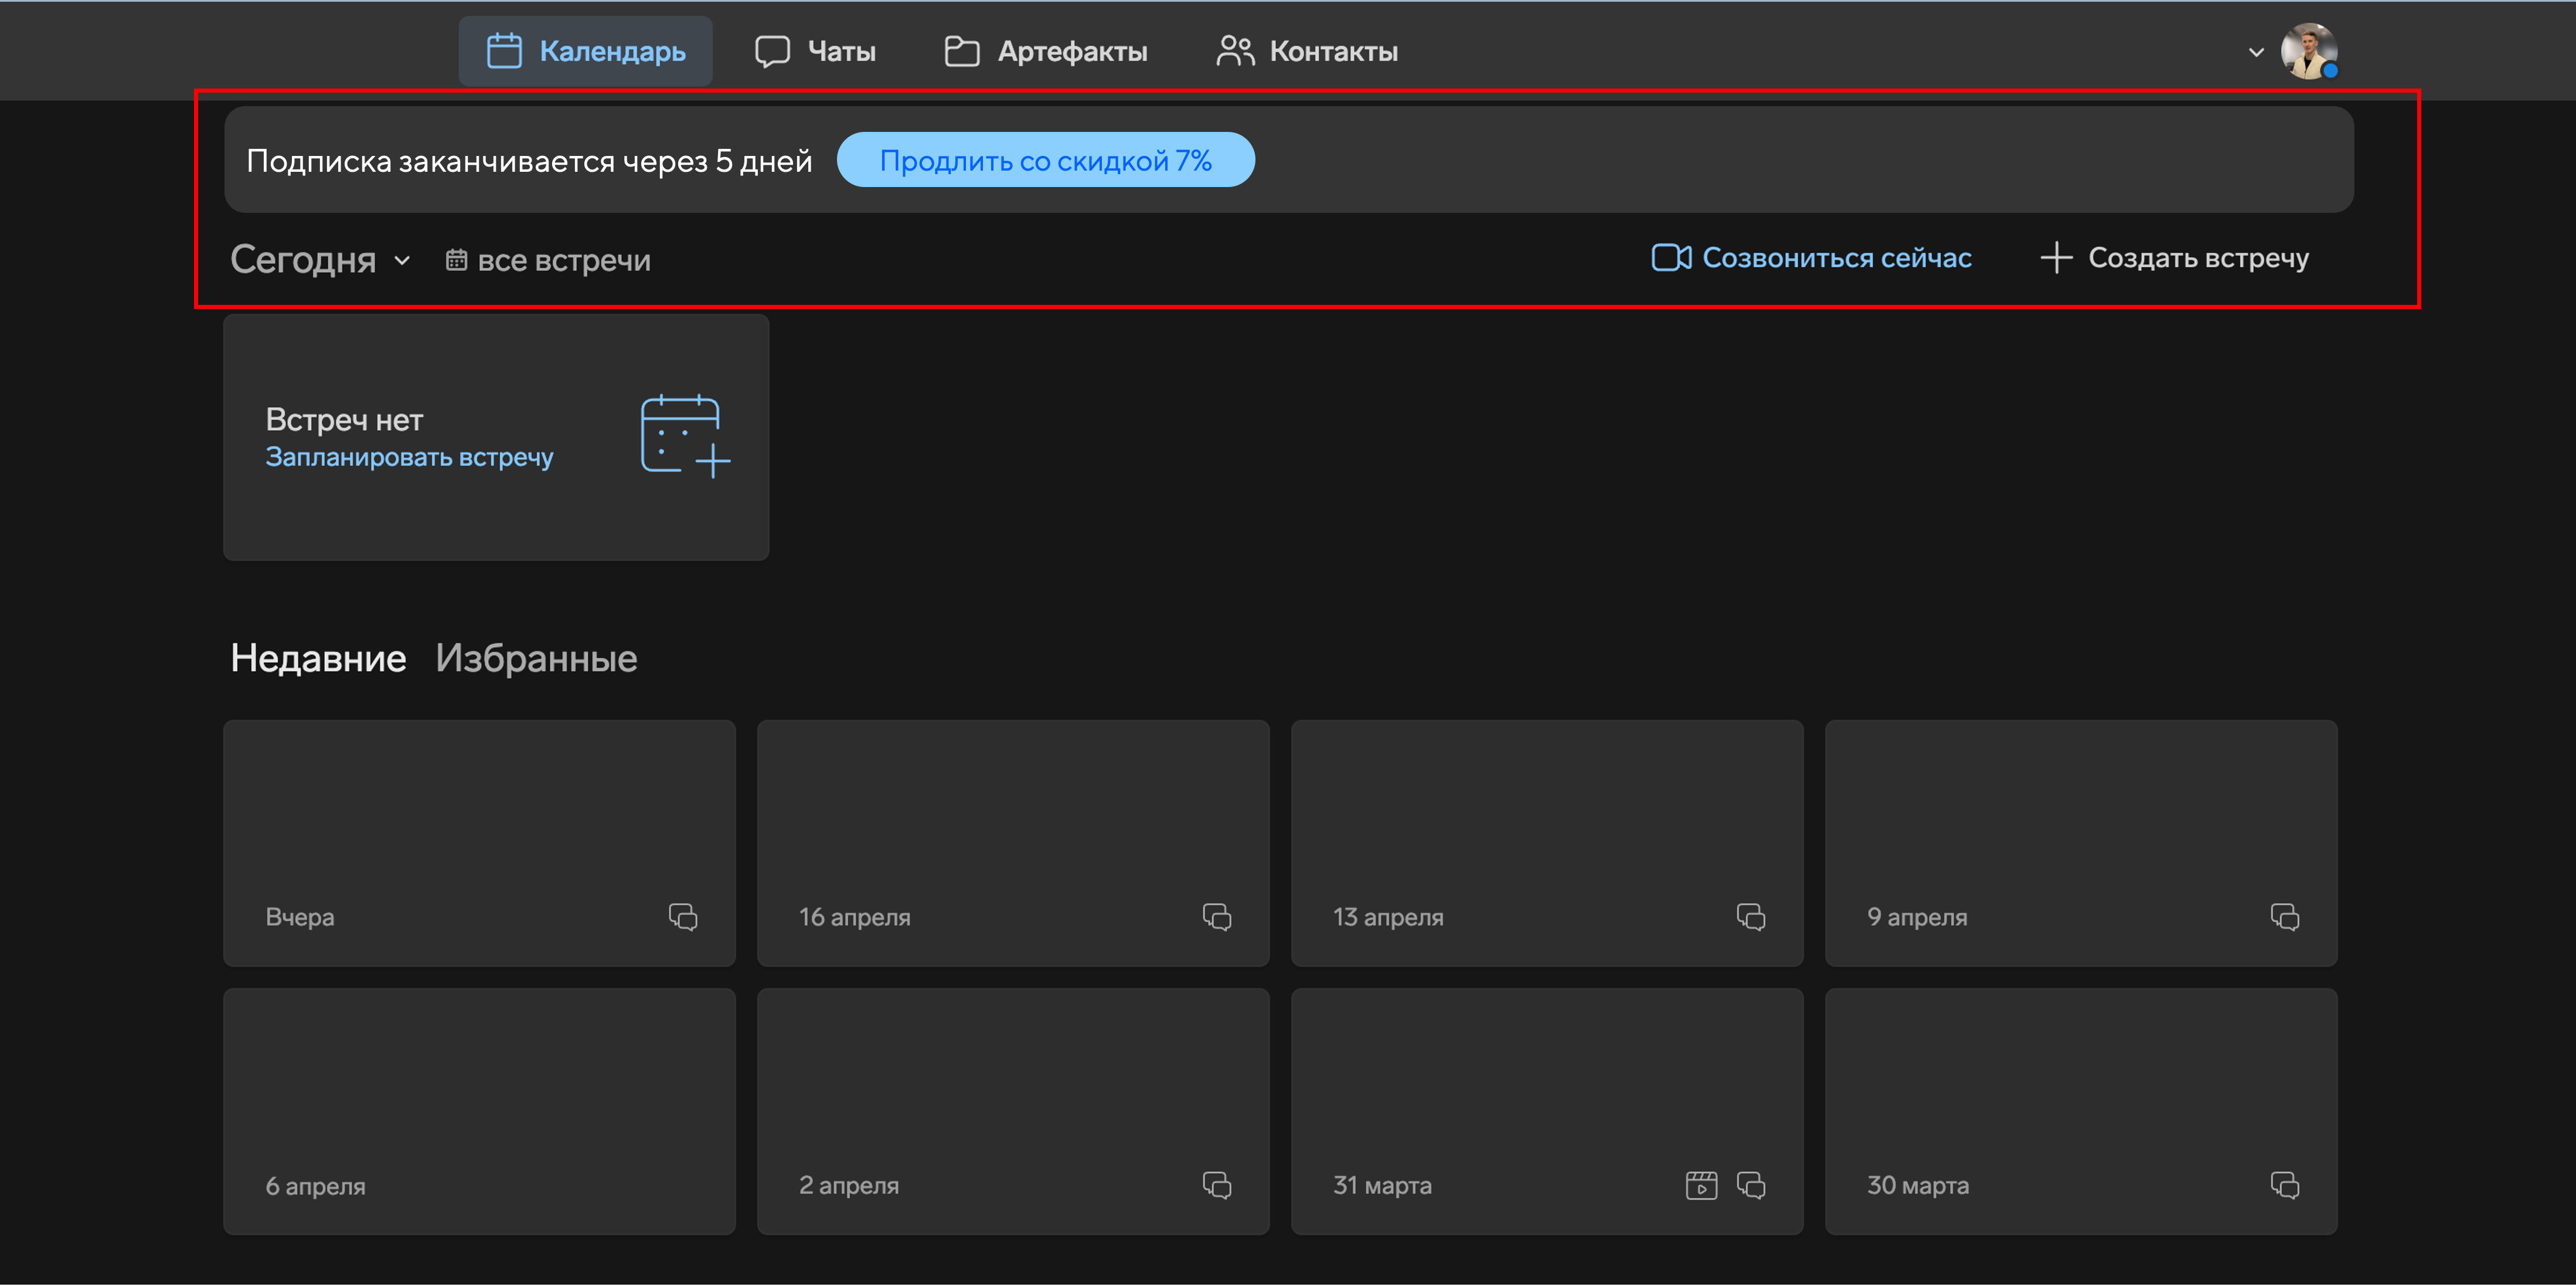

# Анализ проблемы и валидация продуктовой идеи

In [1109]:
# Импорт библиотек
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.stats import chisquare

1. Проверка платного retention клиентов по датам. Отобрал клиентов, удовлетворяющим следующим требованиям:
   - месячный триал клиента истекает в 2026 году
   - в продлениях учтены только подключения месячных подписок по тарифам и из перечня на сайте (их мы будем предлагать подключить в АВС-тесте)

In [18]:
expired_churn = pd.read_csv("Expired_churn.csv", decimal = ',')
expired_churn = expired_churn.drop(['cr_to_paid', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', '3'], axis = 1)
expired_churn = expired_churn.rename(columns = {'create_dt':'cohort', 'cnt':'retained'})
expired_churn['cohort'] = pd.to_datetime(expired_churn['cohort'])
expired_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   cohort                 110 non-null    datetime64[ns]
 1   expired_trials         110 non-null    int64         
 2   retained               110 non-null    int64         
 3   expired_profi          110 non-null    int64         
 4   expired_business       110 non-null    int64         
 5   expired_business_plus  110 non-null    int64         
 6   profi_price            110 non-null    int64         
 7   business_price         110 non-null    int64         
 8   pusiness_plus_price    110 non-null    int64         
 9   retention_revenue      110 non-null    int64         
 10  arpu                   110 non-null    int64         
dtypes: datetime64[ns](1), int64(10)
memory usage: 9.6 KB


In [20]:
expired_churn.head()

,cohort,expired_trials,retained,expired_profi,expired_business,expired_business_plus,profi_price,business_price,pusiness_plus_price,retention_revenue,arpu
0,2026-01-01,45,5,2,2,1,1390,2200,2700,9880,1976
1,2026-01-02,176,16,8,6,2,1390,2200,2700,29720,1858
2,2026-01-03,220,22,11,8,3,1390,2200,2700,40990,1863
3,2026-01-04,180,18,9,7,2,1390,2200,2700,33310,1851
4,2026-01-05,130,26,13,10,3,1390,2200,2700,48170,1853


2. Получается, что конверсия указанного сегмента клиентов в платную подписку составляет 13%

In [23]:
expired_churn['cr_to_paid'] = np.round(expired_churn['retained'] / expired_churn['expired_trials'],2)
print(f'средняя конверсия триала в месячные подписки = {np.round(expired_churn['cr_to_paid'].mean(),2)}')

средняя конверсия триала в месячные подписки = 0.12


На долю этого сегмена приходится менее 8% всех клиентов продукта.
Главная проблема в этом клиентском сегменте - он не приносит денег. При среднем CAC 8,1 тыс. руб., LTV клиента составляет 7,7 тыс. руб.
При этом, при прочих равных, чтобы выйти на желаемое соотношение LTV/CAC = 3, конверсия в платного клиента должна быть на уровне 31%.

In [26]:
summary = pd.read_csv('Talk_summary.csv')
summary

,Metric,Jan,Feb,Mar,Apr
0,Leads,8761,9418,9322,6713
1,Paid_prolongations,1199,1171,1275,849
2,CR,"0,14","0,12","0,14","0,13"
3,CAC,8640,9301,8399,8522
4,LTV,9937,6716,6896,7094
5,LTV/CAC,"1,15","0,72","0,82","0,83"


Бизнес считает, что рост конверсии в подключение после триала на 2 п.п. будет хорошим результатом изменений. Посмотрим, как это отразится на выручке сегмента

### Вывод по исследованию ниже:
1. Из-за того, что нам точно неизвестно, как распределятся новые потенциальные платные клиенты по тарифам, потенциальный прирост конверсии +2 п.п. может вообще не принести дополнительной выручки, если все эти клиенты пойдут на тариф "Профи". 1 клиент, пришедший на тариф "Бизнес-плюс приносит столько же денег, сколько 2 клиента на тарифе "Профи"
2. Систематический аплифт выручки (в варианте без скидки!) получается при росте конверсии на +3 п.п. и более
3. В варианте со скидкой аплифт также наблюдается только при росте конверсии не менее +3 п.п.
4. Анализ прошлых похожих экспериментов с баннерами показал, что в среднем подобные изменения дают эффект +3-4 п.п. конверсии
5. Таким образом, тезис о полезном приросте триала на 2 п.п. отклоняется. +2 п.п. недостаточно для бизнес-эффекта, целевой уровень — ≥ +3 п.п., при этом нужно проверить достижимость такого эффекта

In [1123]:
# Определим ожидаемый прирост конверсии
expected_delta_1 = 0.02
expected_delta_2 = 0.03
expected_delta_3 = 0.04

# Ниже определны доли клиентов каждого тарифа Толка в общей структуре продлений
profi_share = 0.5
business_share = 0.4
business_plus_share = 0.1

# Копируем датафрейм для расчета ожидаемых эффектов
expected_df = expired_churn.copy()
expected_df.head(3)

,cohort,expired_trials,retained,expired_profi,expired_business,expired_business_plus,profi_price,business_price,pusiness_plus_price,retention_revenue,arpu,cr_to_paid
0,2026-01-01,45,5,2,2,1,1390,2200,2700,9880,1976,0.11
1,2026-01-02,176,16,8,6,2,1390,2200,2700,29720,1858,0.09
2,2026-01-03,220,22,11,8,3,1390,2200,2700,40990,1863,0.10


In [32]:
# Рассчитаем ожидаемую конверсию после триала с учетом предлагаемых изменений

expected_df['retained_expected_sc1'] = np.ceil(expected_df['expired_trials']*(expected_df['cr_to_paid']+expected_delta_1))
expected_df['retained_expected_sc2'] = np.ceil(expected_df['expired_trials']*(expected_df['cr_to_paid']+expected_delta_2))
expected_df['retained_expected_sc3'] = np.ceil(expected_df['expired_trials']*(expected_df['cr_to_paid']+expected_delta_3))

expected_df[['retained', 'retained_expected_sc1', 'retained_expected_sc2', 'retained_expected_sc3']].head(3)

,retained,retained_expected_sc1,retained_expected_sc2,retained_expected_sc3
0,5,6.0,7.0,7.0
1,16,20.0,22.0,23.0
2,22,27.0,29.0,31.0


In [34]:
# СЦЕНАРИЙ 1 -- Рассчитаем ожидаемое число клиентов по каждому из тарифов, чтобы далее рассчитать ожидаемую выручку

expected_df['profi_share_sc1'] = np.ceil(expected_df['retained_expected_sc1']*profi_share)
expected_df['business_share_sc1'] = np.floor(expected_df['retained_expected_sc1']*business_share)
expected_df['business_plus_share_sc1'] = expected_df['retained_expected_sc1'] - \
expected_df['business_share_sc1'] - expected_df['profi_share_sc1']
expected_df[['profi_share_sc1', 'business_share_sc1', 'business_plus_share_sc1']].head(3)

,profi_share_sc1,business_share_sc1,business_plus_share_sc1
0,3.0,2.0,1.0
1,10.0,8.0,2.0
2,14.0,10.0,3.0


In [36]:
# СЦЕНАРИЙ 2 -- Рассчитаем ожидаемое число клиентов по каждому из тарифов, чтобы далее рассчитать ожидаемую выручку

expected_df['profi_share_sc2'] = np.ceil(expected_df['retained_expected_sc2']*profi_share)
expected_df['business_share_sc2'] = np.floor(expected_df['retained_expected_sc2']*business_share)
expected_df['business_plus_share_sc2'] = expected_df['retained_expected_sc2'] - \
expected_df['business_share_sc2'] - expected_df['profi_share_sc2']
expected_df[['profi_share_sc2', 'business_share_sc2', 'business_plus_share_sc2']].head(3)

,profi_share_sc2,business_share_sc2,business_plus_share_sc2
0,4.0,2.0,1.0
1,11.0,8.0,3.0
2,15.0,11.0,3.0


In [38]:
# СЦЕНАРИЙ 3 -- Рассчитаем ожидаемое число клиентов по каждому из тарифов, чтобы далее рассчитать ожидаемую выручку

expected_df['profi_share_sc3'] = np.ceil(expected_df['retained_expected_sc3']*profi_share)
expected_df['business_share_sc3'] = np.floor(expected_df['retained_expected_sc3']*business_share)
expected_df['business_plus_share_sc3'] = expected_df['retained_expected_sc3'] - \
expected_df['business_share_sc3'] - expected_df['profi_share_sc3']
expected_df[['profi_share_sc3', 'business_share_sc3', 'business_plus_share_sc3']].head(3)

,profi_share_sc3,business_share_sc3,business_plus_share_sc3
0,4.0,2.0,1.0
1,12.0,9.0,2.0
2,16.0,12.0,3.0


In [40]:
# Рассчитаем ожидаемую выручку - treatment_1 - без скидки
# Scenario 1

expected_df['exp_revenue_sc1'] = expected_df['profi_share_sc1'] * expected_df['profi_price'] + \
                             expected_df['business_share_sc1'] * expected_df['business_price'] + \
                             expected_df['business_plus_share_sc1'] * expected_df['expired_business_plus']

# Scenario 2

expected_df['exp_revenue_sc2'] = expected_df['profi_share_sc2'] * expected_df['profi_price'] + \
                             expected_df['business_share_sc2'] * expected_df['business_price'] + \
                             expected_df['business_plus_share_sc2'] * expected_df['expired_business_plus']

# Scenario 3

expected_df['exp_revenue_sc3'] = expected_df['profi_share_sc3'] * expected_df['profi_price'] + \
                             expected_df['business_share_sc3'] * expected_df['business_price'] + \
                             expected_df['business_plus_share_sc3'] * expected_df['expired_business_plus']


# Рассчитаем ожидаемую выручку - treatment_2 - со скидкой

expected_df['discount'] = 0.07
expected_df['exp_revenue_sc1_discount'] = expected_df['profi_share_sc1'] * expected_df['profi_price'] * \
                             (1-expected_df['discount'])+ \
                             expected_df['business_share_sc1'] * expected_df['business_price'] + \
                             expected_df['business_plus_share_sc1'] * expected_df['expired_business_plus']

# Scenario 2

expected_df['exp_revenue_sc2_discount'] = expected_df['profi_share_sc2'] * expected_df['profi_price'] * \
                             (1-expected_df['discount'])+ \
                             expected_df['business_share_sc2'] * expected_df['business_price'] + \
                             expected_df['business_plus_share_sc2'] * expected_df['expired_business_plus']

# Scenario 3

expected_df['exp_revenue_sc3_discount'] = expected_df['profi_share_sc3'] * expected_df['profi_price'] * \
                             (1-expected_df['discount'])+ \
                             expected_df['business_share_sc3'] * expected_df['business_price'] + \
                             expected_df['business_plus_share_sc3'] * expected_df['expired_business_plus']

In [42]:
# Оставим результаты только за апрель и посмотрим, что получилось по выручке
revenue_comp = expected_df[expected_df['cohort'] >= '2026-04-01']

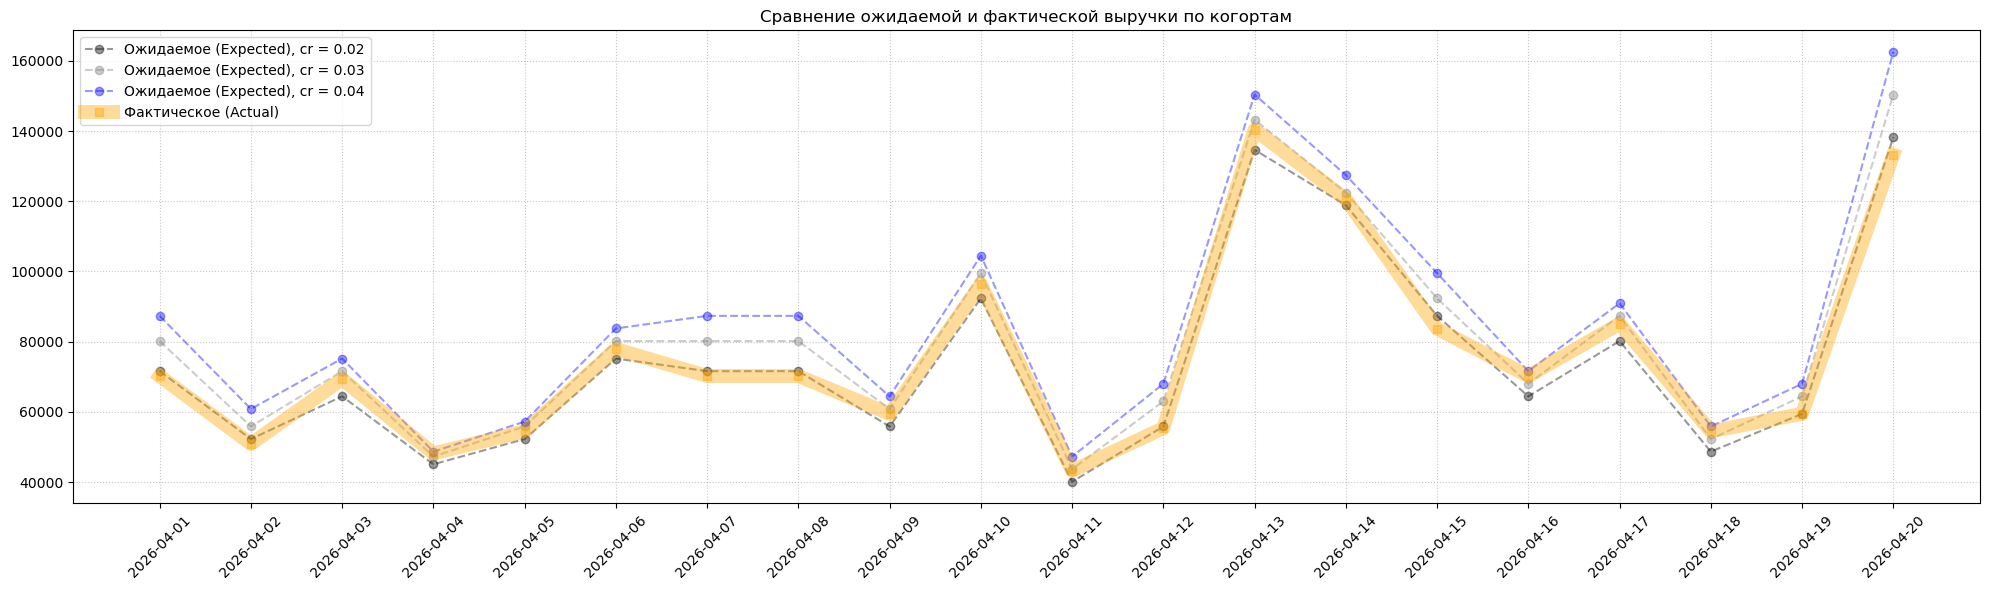

In [44]:
plt.figure(figsize = (20,6))
#=================================================================================
plt.plot(revenue_comp['cohort'].astype(str), revenue_comp['exp_revenue_sc1'], 
         label=(f'Ожидаемое (Expected), cr = {expected_delta_1}'), marker='o', linestyle='--', color = 'black', alpha = 0.4)
plt.plot(revenue_comp['cohort'].astype(str), revenue_comp['exp_revenue_sc2'], 
         label=(f'Ожидаемое (Expected), cr = {expected_delta_2}'), marker='o', linestyle='--', color = 'grey', alpha = 0.4)
plt.plot(revenue_comp['cohort'].astype(str), revenue_comp['exp_revenue_sc3'], 
         label=(f'Ожидаемое (Expected), cr = {expected_delta_3}'), marker='o', linestyle='--', color = 'blue', alpha = 0.4)
plt.plot(revenue_comp['cohort'].astype(str), revenue_comp['retention_revenue'], 
         label='Фактическое (Actual)', marker='s', color = 'orange', alpha = 0.4, linewidth=10)
#=================================================================================
# Оформление
plt.title('Сравнение ожидаемой и фактической выручки по когортам')
plt.xticks(rotation=45) # Наклоняем подписи дат для удобства
plt.legend() # Добавляем легенду
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [45]:
revenue_comp.agg({'retention_revenue':'sum', 'exp_revenue_sc1':'sum', 'exp_revenue_sc2':'sum', 'exp_revenue_sc3':'sum'})

retention_revenue    1512760.0
exp_revenue_sc1      1479750.0
exp_revenue_sc2      1598580.0
exp_revenue_sc3      1698111.0
dtype: float64

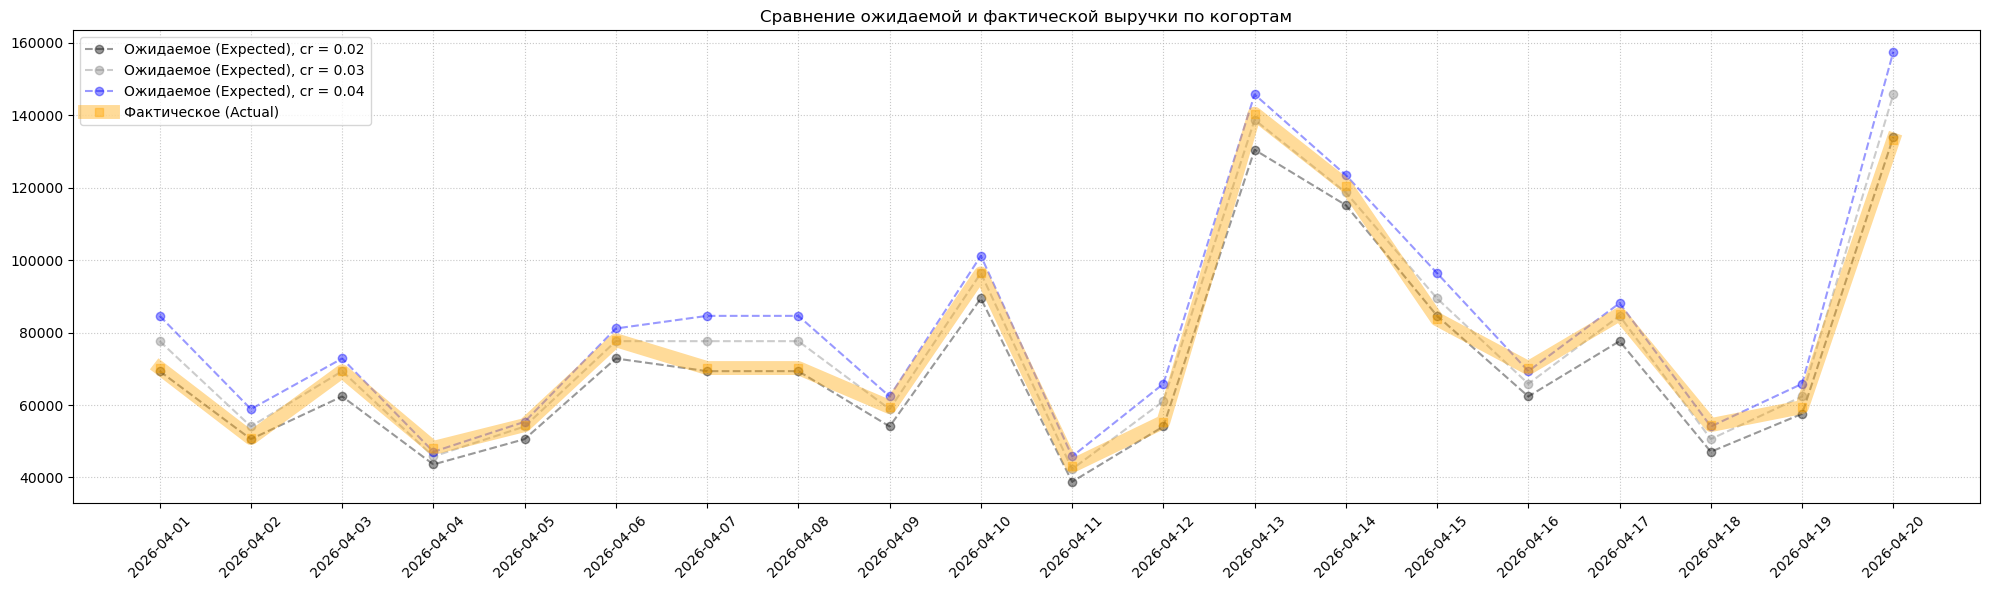

In [48]:
plt.figure(figsize = (20,6))
#=================================================================================
plt.plot(revenue_comp['cohort'].astype(str), revenue_comp['exp_revenue_sc1_discount'], 
         label=(f'Ожидаемое (Expected), cr = {expected_delta_1}'), marker='o', linestyle='--', color = 'black', alpha = 0.4)
plt.plot(revenue_comp['cohort'].astype(str), revenue_comp['exp_revenue_sc2_discount'], 
         label=(f'Ожидаемое (Expected), cr = {expected_delta_2}'), marker='o', linestyle='--', color = 'grey', alpha = 0.4)
plt.plot(revenue_comp['cohort'].astype(str), revenue_comp['exp_revenue_sc3_discount'], 
         label=(f'Ожидаемое (Expected), cr = {expected_delta_3}'), marker='o', linestyle='--', color = 'blue', alpha = 0.4)
plt.plot(revenue_comp['cohort'].astype(str), revenue_comp['retention_revenue'], 
         label='Фактическое (Actual)', marker='s', color = 'orange', alpha = 0.4, linewidth=10)
#=================================================================================
# Оформление
plt.title('Сравнение ожидаемой и фактической выручки по когортам')
plt.xticks(rotation=45) # Наклоняем подписи дат для удобства
plt.legend() # Добавляем легенду
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [49]:
revenue_comp.agg({'retention_revenue':'sum', 'exp_revenue_sc1_discount':'sum', 'exp_revenue_sc2_discount':'sum', 'exp_revenue_sc3_discount':'sum'})

retention_revenue           1512760.0
exp_revenue_sc1_discount    1433337.9
exp_revenue_sc2_discount    1548470.5
exp_revenue_sc3_discount    1644887.9
dtype: float64

In [52]:
(revenue_comp['profi_share_sc3'].sum() + revenue_comp['business_share_sc3'].sum() +revenue_comp['business_plus_share_sc3'].sum())- revenue_comp['retained'].sum()

270.0

## Формулирование продуктовой гипотезы

Баннер на главной странице с предложением продлить подписку повысит конверсию из триала в платного клиента с месячной подпиской не менее, чем на 3%. Обеим тестовым группам будут показаны только месячные подписочные планы.

Техническая реализация:
1. Определить сроки размещения баннера
2. Согласовать с продактом
3. Внести информацию в календарь баннеров
4. Аппрув от копирайтеров
5. ТЗ дизайнерам
6. Сделать заявку в поддержку с указанием всей подробной информации о баннере по форме

## Определение целевой аудитории и сегмента для онлайн-эксперимента

- Клиенты, у которых в ближайшие 10 дней заканчивается триал по сервису "Видеовстречи"
Устройства: и десктоп и мобила
- Не госы (т.е. можем зафиксировать факт оплаты)
- Активные (были активные сессии длиной более 5 минут за последние 5 дней)
- Не в числе клиентов, которым отправлены иные спецпредложения за последние 30 дней

## Выбор метрик

1. <b>Ключевая метрика</b> - конверсия в оплату за 10 дней. Если клиент стал платным через 10 дней после окончания триала, считаем, что баннер сыграл роль. Выбор обусловлен тем, что цель напоминания о продлении - повысить конверсию в оплату. 
2. <b>Прокси-метрика</b> - выручка продлений
3. <b>Защитная метрика</b> - contribution margin

Дополнительные метрики:
- среднее время до продления
- каннибализация скидки: сколько клиентов бы продлились без скидки

## Порядок приемки теста

1. Тест останавливается при консистентном ухудшении целевой, вспомогательной или защитной метрики в течение как минимум 3 дней
2. Тест останавливается при наличии высокой уверенности в возможном баге, верифицированном QA или разработчиком
3. Тест принимается по основной и единственной метрике. Успехом считается ее статзначимое улучшение на фоне отсутствия ухудшения прокси и защитной метрики
4. Стандартный уровень альфа: для основной метрики - 0.05, для второстепенных и защитных - 0.01
5. Для основной метрики тестируется улучшающая односторонняя гипотеза, для второстепенных метрик - двусторонняя гипотеза
6. Для защитной метрики тестируется ухудшающая односторонняя гипотеза
7. Любые изменения метрики, ниже уровня MDE при заданном уровне трафика, считаются случайными и не могут быть использованы для принятия решения по результатам теста

##  Правила перезапуска

1. В случае невалидности предыдущего запуска теста, а также проведенной работе по устранению багов.
2. При неудачном проведении теста, после проведенной работы над ошибками, как в технической, продуктовой, или же UI/UX-частях.
3. Запрещается проводить перезапуск теста без видимых оснований или без проведенной работы над исправлением работоспособности
функционала. В таком случае перезапуск расценивается как попытка получить более благоприятный исход теста в силу случайности поведения
метрик.

## Параметры дизайна А/B/C - эксперимента

- alpha = 0.05
- beta = 0.2
- power = 0.8
- выбранный метод оценки статистики: Тест Хи-квадрат
- особенности дизайна: поправка на множественное тестирование

### Термины, используемые в дизайне А/Б теста
- ошибка 1 рода - отклонить верную нулевую гипотезу (false positive)
- ошибка 2 рода - не отклонить неверную нулевую гипотезу (false negative)
- p-value - вероятность получить наблюдаемые или еще более сильные отклонения при условии, что верна нулевая гипотеза. Говоря проще, p-value - это мера того, насколько наблюдаемый результат мог получиться случайно

### Family-wise error rate

$$
FWER = 1 - (1 - \alpha)^m
$$

In [72]:
alpha = 0.05
beta = 0.2
power = 1 - beta
hypothesis_cnt = 2

Из-за множественных сравнений уровень ошибки 1 рода вырастет с 0.05 до 0.14. Это значит, что риск засечь изменения там, где их нет на самом деле, вырастает в 3 раза

In [75]:
fwer = 1 - (1-alpha)**hypothesis_cnt
fwer

0.09750000000000003

В целях контроля уровня ошибки 1 рода, примем групповой уровень значимости как:

In [78]:
group_alpha = np.round(alpha/hypothesis_cnt,3)
group_alpha

0.025

In [80]:
expired_churn['cr_to_paid'].mean()

0.12454545454545453

In [317]:
122000*0.17

20740.0

In [82]:
# 89k - трафик сайта
#5% - доля исследуемого сегмента в трафике = 4,5k в месяц
#конверсия - 4к * 13% = 579 чел

In [311]:
alpha = 0.05
beta = 0.2
power = 1 - beta

hypothesis_cnt = 3
group_alpha = alpha / hypothesis_cnt

p_a = expired_churn['cr_to_paid'].mean()

delta_ba = 0.03 # аплифт продуктовой гипотезы
delta_cb = 0.02 # предположение по аплифту конверсии в группе C относительно группы B

p_b = p_a + delta_ba
p_c = p_b + delta_cb

def sample_size_proportion_one_sided(p1, p2, alpha=group_alpha, power=power):
    mde = p2 - p1

    var1 = p1 * (1 - p1)
    var2 = p2 * (1 - p2)

    z_alpha = norm.ppf(1 - alpha)
    z_beta = norm.ppf(power)

    size = ((z_alpha + z_beta) ** 2 * (var1 + var2)) / (mde ** 2)

    return int(np.ceil(size))

n_ba = sample_size_proportion_one_sided(p_a, p_b)
n_ca = sample_size_proportion_one_sided(p_a, p_c)
n_cb = sample_size_proportion_one_sided(p_b, p_c)

n = max(n_ba, n_ca, n_cb)

print(f"B vs A: {n_ba}")
print(f"C vs A: {n_ca}")
print(f"C vs B: {n_cb}")
print(f"Итоговый размер группы = {n}")
print(f"Размер выборки под A/B/C тест = {n * 3}")

B vs A: 2349
C vs A: 893
C vs B: 6058
Итоговый размер группы = 6058
Размер выборки под A/B/C тест = 18174


- Трафик главной страницы в месяц: 122 310 уников. (март 2026)
- Общий трафик целевого сегмента: 20 740 пользователей в месяц
- Чтобы набрать группы для теста, нужно закладывать 5 недель

# Контроль уровня ошибки I рода (FWER)

In [333]:
p_sim_a = 0.13
p_sim_b = 0.13
p_sim_c = 0.13
n = n
false_positives = []

for i in range(1000):
    group_a = np.random.binomial(1, p_sim_a, n)
    group_b = np.random.binomial(1, p_sim_b, n)
    group_c = np.random.binomial(1, p_sim_c, n)
    
    success_a = group_a.sum()
    success_b = group_b.sum()
    success_c = group_c.sum()

    _, p_ba = proportions_ztest([success_b, success_a], [n, n], alternative='larger')
    _, p_ca = proportions_ztest([success_c, success_a], [n, n], alternative='larger')
    _, p_cb = proportions_ztest([success_c, success_b], [n, n], alternative='larger')

    reject, _, _, _ = multipletests([p_ba, p_ca, p_cb], alpha=0.05, method='holm')
    false_positives.append(reject.any())
np.mean(false_positives)

0.045

Для проверки контролируемости ошибки 1 рода возьмем исторические данные за 1 неделю до эксперимента и проверим дизайн

In [362]:
pre_abc_data = pd.read_csv("pre_abc_data.csv")[['date', 'trial_end_date', 'h_clients_hk', 'Test_group', 'Prolongation_tariff', 'prolongation_date', 'price_payed', 'converted']]

In [364]:
pre_abc_data['date'] = pd.to_datetime(pre_abc_data['date'], dayfirst = True)
pre_abc_data['trial_end_date'] = pd.to_datetime(pre_abc_data['trial_end_date'], dayfirst = True)
pre_abc_data['prolongation_date'] = pd.to_datetime(pre_abc_data['prolongation_date'], dayfirst = True)
pre_abc_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4104 entries, 0 to 4103
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 4104 non-null   datetime64[ns]
 1   trial_end_date       4104 non-null   datetime64[ns]
 2   h_clients_hk         4104 non-null   object        
 3   Test_group           4104 non-null   object        
 4   Prolongation_tariff  4104 non-null   object        
 5   prolongation_date    4104 non-null   datetime64[ns]
 6   price_payed          4104 non-null   int64         
 7   converted            4104 non-null   int64         
dtypes: datetime64[ns](3), int64(2), object(3)
memory usage: 256.6+ KB


### Ниже на исторических данных убедились, что контролируем уровень ошибки 1 рода:

In [443]:
false_positives_hist = []
users = pre_abc_data['h_clients_hk'].unique()

for i in range(500):
    np.random.shuffle(users)
    group_a = users[:len(users)//3]
    group_b = users[len(users)//3:len(users)//3*2]
    group_c = users[len(users)//3*2:]
    cr_a = pre_abc_data[pre_abc_data['h_clients_hk'].isin(group_a)]['converted'].sum()
    cr_b = pre_abc_data[pre_abc_data['h_clients_hk'].isin(group_b)]['converted'].sum()
    cr_c = pre_abc_data[pre_abc_data['h_clients_hk'].isin(group_c)]['converted'].sum()
    _, p_ba = proportions_ztest([cr_b, cr_a], [len(group_b), len(group_a)], alternative='larger')
    _, p_ca = proportions_ztest([cr_c, cr_a], [len(group_c), len(group_a)], alternative='larger')
    _, p_cb = proportions_ztest([cr_c, cr_b], [len(group_c), len(group_b)], alternative='larger')
    reject, _, _, _ = multipletests([p_ba, p_ca, p_cb], alpha=0.05, method='holm')
    false_positives_hist.append(reject.any())

print(len(group_a))
print(len(group_b))
print(len(group_c))
print(np.mean(false_positives_hist))

1368
1368
1368
0.024


# Контроль ошибки II рода

Из-за необходимости сравнивать между собой варианты B и С, тест получился значительно мощнее и строже, чем этого требует простое сравнение A и B. Поскольку для сравнения между собой вариантов B и C необходимо набрать в 3 раза больше элементов в группы, то и для остальных групп необходимо набрать такое же число элементов

In [462]:
p_a = 0.13
p_b = p_a + 0.03
p_c = p_b + 0.02  # если C на 3 п.п. выше B

n = 6058
power_ba = []
power_cb = []

for i in range(500):
    group_a = np.random.binomial(1, p_a, n)
    group_b = np.random.binomial(1, p_b, n)
    group_c = np.random.binomial(1, p_c, n)

    success_a = group_a.sum()
    success_b = group_b.sum()
    success_c = group_c.sum()

    _, p_ba = proportions_ztest([success_b, success_a], [n, n], alternative='larger')
    _, p_ca = proportions_ztest([success_c, success_a], [n, n], alternative='larger')
    _, p_cb = proportions_ztest([success_c, success_b], [n, n], alternative='larger')

    reject, _, _, _ = multipletests(
        [p_ba, p_ca, p_cb],
        alpha=0.05,
        method='holm'
    )

    power_ba.append(reject[0])  # B > A
    power_cb.append(reject[2])  # C > B

print(f"Power B vs A: {np.mean(power_ba):.4f}")
print(f"Beta B vs A: {1 - np.mean(power_ba):.4f}")

print(f"Power C vs B: {np.mean(power_cb):.4f}")
print(f"Beta C vs B: {1 - np.mean(power_cb):.4f}")

Power B vs A: 1.0000
Beta B vs A: 0.0000
Power C vs B: 0.9060
Beta C vs B: 0.0940


In [470]:
pre_abc_data['date'].max()

Timestamp('2026-03-22 00:00:00')

## Проведение теста

По расчетам ниже получили результат, что обе гипотезы, а именно:
- B vs A
- C vs B

значимо отличаются друг от друга

In [1015]:
abc_data = pd.read_csv("Conversion_abc_test_.csv", decimal = ",")[['date', 'trial_end_date', 'h_clients_hk', 'Test_group', 'Prolongation_tariff', 'prolongation_date', 'price_payed', 'converted']]
abc_data
abc_data['price_payed'] = abc_data['price_payed'].astype(int)

In [1017]:
abc_data['price_payed'] = np.where(abc_data['converted'] == 1, abc_data['price_payed'], 0)

### Контроль SRM

p-value = 1 --> SRM нет

In [1021]:
observes = (
    abc_data
    .groupby('Test_group')['h_clients_hk']
    .nunique()
)

observed = observes.values

# ожидаем равный сплит
expected = np.array([n, n, n])

stat, p = chisquare(f_obs=observed, f_exp=expected)

print("Observed:", observed)
print("Expected:", expected)
print("p-value:", p)

Observed: [6058 6058 6058]
Expected: [6058 6058 6058]
p-value: 1.0


In [1023]:
abc_data['trial_end_date'] = pd.to_datetime(abc_data['trial_end_date'], dayfirst=True, errors='coerce')
abc_data['prolongation_date'] = pd.to_datetime(abc_data['prolongation_date'], dayfirst=True, errors='coerce')
abc_data['date'] = pd.to_datetime(abc_data['date'], dayfirst=True, errors='coerce')

In [1025]:
print(abc_data['date'].dt.date.min())
print(abc_data['date'].dt.date.max())

2026-03-23
2026-04-30


In [1027]:
# сравниваем результаты группы B и A
# сравниваем результаты группы C и A

In [1029]:
group_a = abc_data.copy()
group_a = group_a[group_a['Test_group'] == 'A']
group_b = abc_data.copy()
group_b = group_b[group_b['Test_group'] == 'B']
group_c = abc_data.copy()
group_c = group_c[group_c['Test_group'] == 'C']

# конверсии
conversion_a = group_a['converted'].mean()
conversion_b = group_b['converted'].mean()
conversion_c = group_c['converted'].mean()

print(conversion_a, conversion_b, conversion_c)

# успехи
a = group_a['converted'].sum()
b = group_b['converted'].sum()
c = group_c['converted'].sum()

# размеры
n_a = group_a['h_clients_hk'].nunique()
n_b = group_b['h_clients_hk'].nunique()
n_c = group_c['h_clients_hk'].nunique()

# one-sided: treatment > control
_, p_ba = proportions_ztest([b, a], [n_b, n_a], alternative='larger')
_, p_ca = proportions_ztest([c, a], [n_c, n_a], alternative='larger')

# Holm
reject, pvals_corrected, _, _ = multipletests([p_ba, p_ca], alpha=0.05, method='holm')

print("p-values:", p_ba, p_ca)
print("reject:", reject)

0.12083195774182899 0.13733905579399142 0.18157807857378672
p-values: 0.0033689367309093776 5.185162677428714e-21
reject: [ True  True]


### Доверительные интервалы

In [1032]:
# confidence interval
# lower_bound = m - norm.ppf(z)*se
# upper_bound = m + norm.ppf(z)*se
# se = sigma/np.square(n)
se_ba = np.sqrt(conversion_b*(1-conversion_b)/n_b + conversion_a*(1-conversion_a)/n_a)
se_bc = np.sqrt(conversion_b*(1-conversion_c)/n_c + conversion_b*(1-conversion_b)/n_b)
q_z = norm.ppf(1-alpha/2)
uplift_ba = conversion_b - conversion_a
uplift_bc = conversion_c - conversion_b
lower_bound_ba = uplift_ba - q_z*se_ba
upper_bound_ba = uplift_ba + q_z*se_ba
lower_bound_bc = uplift_bc - q_z*se_bc
upper_bound_bc = uplift_bc + q_z*se_bc
print(f'границы ДИ для H: B vs A: {np.round(lower_bound_ba,4), np.round(upper_bound_ba,4)}')
print(f'границы ДИ для H: C vs B: {np.round(lower_bound_bc,4), np.round(upper_bound_bc,4)}')

границы ДИ для H: B vs A: (0.0046, 0.0284)
границы ДИ для H: C vs B: (0.0321, 0.0563)


In [1097]:
uplift_ba

0.016507098052162425

In [1099]:
uplift_bc

0.0442390227797953

In [1076]:
daily_revenue_a = (
    group_a
    .groupby('prolongation_date')['price_payed']
    .sum()
    .reset_index()
)
daily_revenue_a = daily_revenue_a.sort_values('prolongation_date')
daily_revenue_a['cumsum_revenue'] = daily_revenue_a['price_payed'].cumsum()

In [1078]:
daily_revenue_b = (
    group_b
    .groupby('prolongation_date')['price_payed']
    .sum()
    .reset_index()
)
daily_revenue_b = daily_revenue_b.sort_values('prolongation_date')
daily_revenue_b['cumsum_revenue'] = daily_revenue_b['price_payed'].cumsum()

In [1080]:
daily_revenue_c = (
    group_c
    .groupby('prolongation_date')['price_payed']
    .sum()
    .reset_index()
)
daily_revenue_c = daily_revenue_c.sort_values('prolongation_date')
daily_revenue_c['cumsum_revenue'] = daily_revenue_c['price_payed'].cumsum()

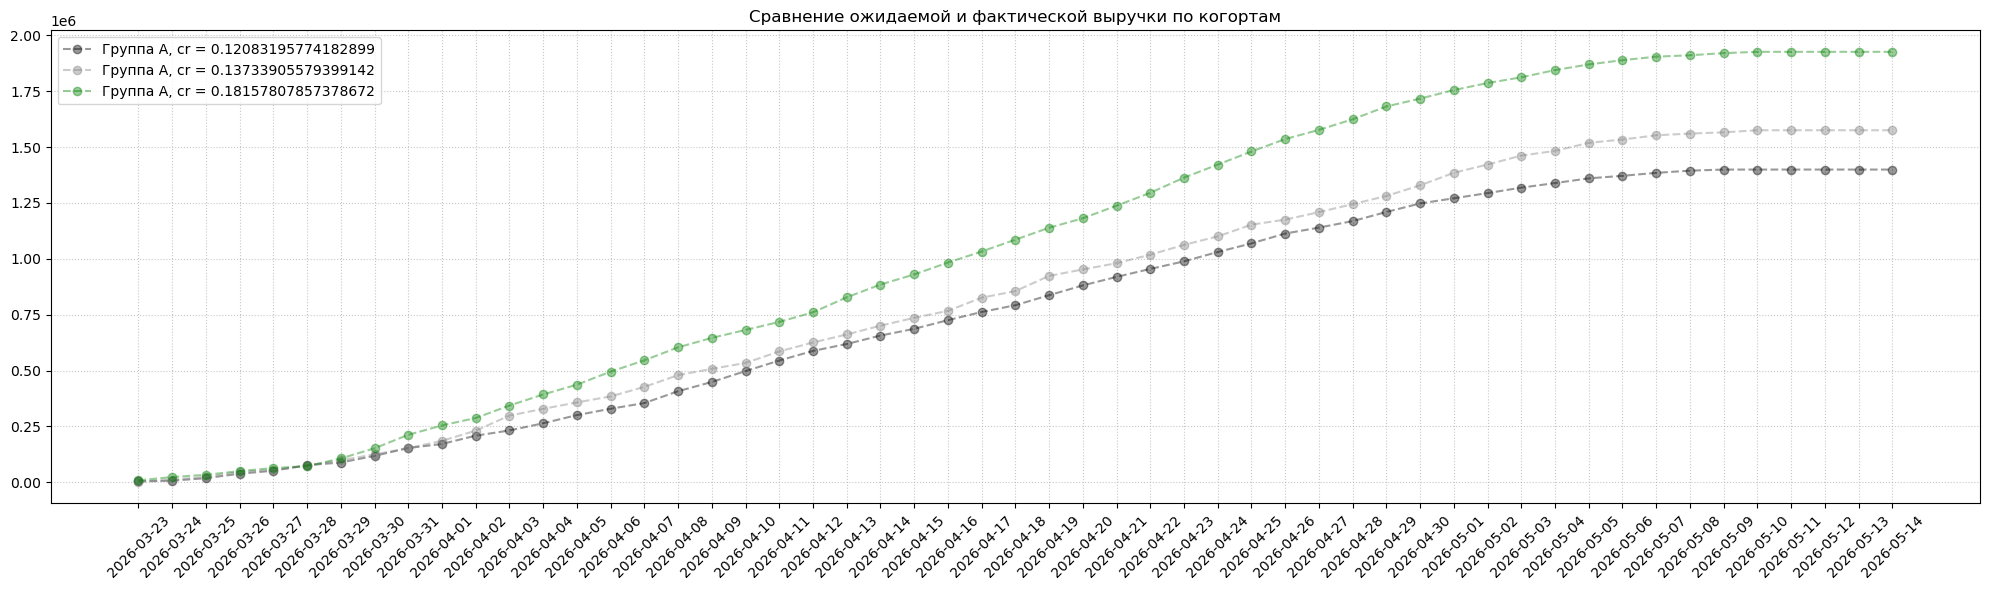

In [1087]:
plt.figure(figsize = (20,6))
#=================================================================================
plt.plot(daily_revenue_a['prolongation_date'].astype(str), daily_revenue_a['cumsum_revenue'], 
         label=(f'Группа А, cr = {conversion_a}'), marker='o', linestyle='--', color = 'black', alpha = 0.4)
plt.plot(daily_revenue_b['prolongation_date'].astype(str), daily_revenue_b['cumsum_revenue'], 
         label=(f'Группа А, cr = {conversion_b}'), marker='o', linestyle='--', color = 'grey', alpha = 0.4)
plt.plot(daily_revenue_c['prolongation_date'].astype(str), daily_revenue_c['cumsum_revenue'], 
         label=(f'Группа А, cr = {conversion_c}'), marker='o', linestyle='--', color = 'green', alpha = 0.4)
#=================================================================================
# Оформление
plt.title('Сравнение ожидаемой и фактической выручки по когортам')
plt.xticks(rotation=45) # Наклоняем подписи дат для удобства
plt.legend() # Добавляем легенду
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [1089]:
a_rev = group_a['price_payed'].sum()
b_rev = group_b['price_payed'].sum()
c_rev = group_c['price_payed'].sum()
print(a_rev)
print(b_rev)
print(c_rev)

1399400
1575300
1926236


In [1095]:
daily_revenue_a['cumsum_revenue'].max()

1399400

In [1093]:
group_a['price_payed'].sum()

1399400

In [985]:
# Выбрать все строки, где в столбце 'date' указана эта дата
asd = group_a.loc[group_a['date'] == '2026-03-23']
asd.iloc[150:]

,date,trial_end_date,h_clients_hk,Test_group,Prolongation_tariff,prolongation_date,price_payed,converted,cumsum_revenue,cumsum_revenue_by_tariff
1910,2026-03-23,2026-03-23,Client_id_1911,A,business_plus,2026-03-26,2700,1,14200,5400
136,2026-03-23,2026-03-23,Client_id_137,A,business_plus,2026-04-06,0,0,14200,5400
5135,2026-03-23,2026-03-23,Client_id_5136,A,business_plus,2026-03-25,2700,1,16900,8100
2915,2026-03-23,2026-03-23,Client_id_2916,A,profi,2026-04-05,0,0,16900,0
2887,2026-03-23,2026-03-23,Client_id_2888,A,profi,2026-03-28,1390,1,18290,1390
2863,2026-03-23,2026-03-23,Client_id_2864,A,profi,2026-03-30,1390,1,19680,2780
2505,2026-03-23,2026-03-23,Client_id_2506,A,profi,2026-03-30,1390,1,21070,4170
2470,2026-03-23,2026-03-23,Client_id_2471,A,profi,2026-03-23,1390,1,22460,5560
1059,2026-03-23,2026-03-23,Client_id_1060,A,profi,2026-04-06,0,0,22460,5560
265,2026-03-23,2026-03-23,Client_id_266,A,profi,2026-03-25,1390,1,23850,6950
